# Modern Statistical Inference

## 1. Standard Monte Carlo Methods

### 1.1 The Core Problem: Intractable Integrals

In mathematics, physics, and statistics, we frequently encounter the need to evaluate expectations or integrals of the form:

$$I = \mathbb{E}_p[f(X)] = \int_{\mathcal{X}} f(x) p(x) dx$$

where $p(x)$ is a probability density function on a potentially high-dimensional space $\mathcal{X}$, and $f(x)$ is some function of interest.

When $\mathcal{X}$ is high-dimensional (e.g., $d > 4$), standard deterministic numerical integration techniques (like the Trapezoidal rule or Simpson's rule) suffer from the curse of dimensionality. Their error scales as $\mathcal{O}(N^{-c/d})$, making them computationally infeasible.

**Deterministic Error Scaling:**

- Suppose we use a total of $N$ evaluation points to form a uniform grid across the $d$-dimensional space.
- The number of divisions along any single dimension is $M = N^{1/d}$.
- The step size (or width of each interval) along one dimension is therefore proportional to $1/M$, meaning $h \propto N^{-1/d}$.
- From classical numerical analysis, if a 1D integration method has an order of accuracy $c$ (e.g., $c=1$ for Riemann sums, $c=2$ for the Trapezoidal rule), its error scales as $\mathcal{O}(h^c)$.
- Substituting our step size $h$ into the 1D error formula gives the overall error for the $d$-dimensional grid:
$$\text{Error} \propto (h)^c = (N^{-1/d})^c = \mathcal{O}(N^{-c/d})$$
Because of this fractional exponent, as the dimension $d$ grows, $c/d$ approaches zero, meaning we need exponentially more points $N$ to achieve the same level of accuracy, i.e. if we have a fixed error tolerance $\epsilon = C \times N^{-c/d} \rightarrow N = (\epsilon/C)^{-d/c} = N_0^d$, where $N_0$ is the number of points needed in 1 dimension by the same numerical method to achieve an error of $\epsilon$ or lower.

### 1.2 The Monte Carlo Solution

The Monte Carlo (MC) method bypasses deterministic grids by using randomness. If we can draw $N$ independent, identically distributed (i.i.d.) samples $x_1, x_2, \dots, x_N \sim p(x)$, we can approximate the integral using the empirical mean:

$$\hat{I}_N = \frac{1}{N} \sum_{i=1}^N f(x_i)$$

**Derivation: Unbiasedness and Convergence**

**Unbiasedness**: The first crucial property of our Monte Carlo estimator is that it is unbiased. This means that, on average, our estimate yields exactly the true integral. Because each sample $x_i$ is drawn from the distribution $p(x)$, the expected value of the function evaluated at any single sample is simply $\mathbb{E}[f(x_i)] = I$. By applying the linearity of expectation, we get:

$$\mathbb{E}[\hat{I}_N] = \mathbb{E}\left[ \frac{1}{N} \sum_{i=1}^N f(x_i) \right] = \frac{1}{N} \sum_{i=1}^N \mathbb{E}[f(x_i)] = \frac{1}{N} \cdot (N \cdot I) = I$$

**Convergence (Strong Law of Large Numbers)**:
While unbiasedness guarantees correctness on average, we also need to know that a specific sequence of samples will eventually hone in on the exact answer. The Strong Law of Large Numbers (SLLN) guarantees that as the number of samples $N$ approaches infinity, our empirical estimate $\hat{I}_N$ converges almost surely ($\xrightarrow{a.s.}$) to the true integral $I$.

To demonstrate algebraically why the probability of the estimate deviating from the true value drops to zero with enough samples, we can prove the Weak Law of Large Numbers (convergence in probability) using *Chebyshev's Inequality*. For any strict error margin $\epsilon > 0$, *Chebyshev's inequality* limits the probability that a random variable deviates from its mean by more than $\epsilon$:

$$P(|\hat{I}_N - \mathbb{E}[\hat{I}_N]| \geq \epsilon) \leq \frac{\text{Var}(\hat{I}_N)}{\epsilon^2}$$

Since our estimator is unbiased ($\mathbb{E}[\hat{I}_N] = I$), and its variance (which we will formally derive in the next step) is $\text{Var}(\hat{I}_N) = \frac{\sigma^2}{N}$, we substitute these values into the inequality:

$$P(|\hat{I}_N - I| \geq \epsilon) \leq \frac{\sigma^2}{N \epsilon^2}$$

Now, we take the limit as the number of samples $N$ goes to infinity:

$$\lim_{N \to \infty} P(|\hat{I}_N - I| \geq \epsilon) \leq \lim_{N \to \infty} \frac{\sigma^2}{N \epsilon^2} = 0$$

This elegantly proves that the probability of our Monte Carlo estimate deviating from the true integral by any non-zero amount shrinks to exactly zero. The SLLN strengthens this further to guarantee the sequence of estimates will converge with probability 1.

**Error Analysis (Central Limit Theorem)**:
To understand how quickly this convergence happens and to quantify our uncertainty, we turn to the Central Limit Theorem (CLT). First, let's define the variance of a single function evaluation under our probability density as $\sigma^2 = \text{Var}_p(f(X)) = \int (f(x) - I)^2 p(x) dx$.

Because our samples $x_1, \dots, x_N$ are independently drawn, the variance of their sum is simply the sum of their individual variances. The variance of our overall estimator $\hat{I}_N$ is thus:

$$\text{Var}(\hat{I}_N) = \text{Var}\left( \frac{1}{N} \sum_{i=1}^N f(x_i) \right) = \left(\frac{1}{N}\right)^2 \sum_{i=1}^N \text{Var}(f(x_i)) = \frac{1}{N^2} (N \cdot \sigma^2) = \frac{\sigma^2}{N}$$

By the Central Limit Theorem, the distribution of the estimation errors becomes Gaussian as $N$ becomes large. Specifically, the standardized error converges in distribution ($\xrightarrow{d}$) to a standard normal distribution:

$$\frac{\hat{I}_N - I}{\sigma / \sqrt{N}} \xrightarrow{d} \mathcal{N}(0, 1)$$

This is incredibly powerful because it allows us to construct standard confidence intervals (e.g., a 95% confidence interval is approximately $\hat{I}_N \pm 1.96 \frac{\sigma}{\sqrt{N}}$). Therefore, the standard error of the MC estimate shrinks at a rate of $\frac{\sigma}{\sqrt{N}}$. Remarkably, **this error rate of $\mathcal{O}(N^{-1/2})$ is entirely independent of the spatial dimension $d$.**

### 1.3 When to use Standard Monte Carlo:

- **High-Dimensional Integration**: Whenever you are evaluating integrals or expectations in spaces where $d > 4$, as the curse of dimensionality makes deterministic grid-based methods utterly fail.

- **Physical Simulations**: When modeling highly complex systems with many interacting components (e.g., lattice QCD in particle physics or rendering equations in computer graphics).

- **Strict Prerequisite**: You must have a mechanism to directly and cheaply draw independent, identically distributed (i.i.d.) samples from the target probability distribution $p(x)$.

## 2. Statistical Inference: Foundations

Before diving into the mechanics of advanced sampling, we must establish what we are trying to achieve with these samples.

### 2.1 What is Inference and Why is it Needed in Physics?

Statistical inference is the process of using data analysis to deduce properties of an underlying probability distribution or physical reality. While probability theory tells us how to generate data from a known model (the forward problem), inference allows us to take observed data and work backward to determine the true nature of the model generating it (the inverse problem).

In physics, inference is absolutely essential. Physical theories (like the Standard Model, thermodynamics, or General Relativity) provide mathematical frameworks governed by specific parameters (e.g., the mass of the Higgs boson, decay rates, or the Hubble constant). However, experiments and observations yield noisy, finite data. Inference acts as the mathematical bridge between theoretical physics and experimental data. It allows us to:

- **Estimate Parameters**: Delineate the true values of fundamental constants from noisy sensor readings.

- **Quantify Uncertainty**: Rigorously calculate the error margins of those measurements, knowing that sensors and environments inherently introduce noise.

- **Hypothesis Testing**: Test competing physical models against one another based on empirical evidence (e.g., does the data support a new particle, or is it just background noise?).

### 2.2 Frequentist vs. Bayesian Paradigms

Historically, there are two dominant paradigms for performing statistical inference, which differ fundamentally in their philosophical definition of probability.

#### 1. Frequentist Inference:

- **Definition of Probability**: Probability is defined strictly as the long-run frequency of repeatable events (e.g., the ratio of "heads" if we flip a coin infinitely many times).

- **Parameters vs. Data**: The true parameters of a physical system ($\theta$) are treated as fixed, but unknown constants. The observed data ($D$) is treated as a random variable.

- **Methodology**: Frequentists rely heavily on the Likelihood function $\mathcal{L}(\theta) = p(D|\theta)$—the probability of observing the data given a specific parameter value. They use techniques like Maximum Likelihood Estimation (MLE) to find the parameter that makes the observed data most mathematically probable. Mathematically, the MLE is the parameter value $\hat{\theta}_{MLE}$ that maximizes this likelihood:

  $$\hat{\theta}_{MLE} = \arg\max_\theta \mathcal{L}(\theta)$$

  Because observations are often assumed to be independent, the joint probability is a product of individual probabilities. To avoid computational underflow with tiny numbers, it is standard practice to instead maximize the sum of the log-likelihoods: $\hat{\theta}_{MLE} = \arg\max_\theta \sum_{i} \log p(x_i | \theta)$.

- **Uncertainty**: Uncertainty is expressed via confidence intervals. A 95% confidence interval means: "If we repeated this exact experiment 100 times, 95 of the calculated intervals would contain the true, fixed parameter." It does not mean there is a 95% chance the parameter is in the specific interval we just calculated. This is a subtle but critical distinction. Because the frequentist paradigm dictates that the true parameter is a fixed constant, it does not have a probability distribution. Therefore, once an interval is computed from a specific dataset (e.g., $[2.4, 3.8]$), the true parameter is either exactly 100% inside that interval, or exactly 0% inside it. The "95%" describes the long-run reliability of the procedure used to generate the intervals, not the probability of the parameter residing in any one single realized interval.

#### 2. Bayesian Inference:

- **Definition of Probability**: Probability represents a "degree of belief" or a state of knowledge about an event or parameter, which can be dynamically updated as new evidence is acquired.

- **Parameters vs. Data**: The observed data ($D$) is treated as fixed (since we have already measured it). The true parameters ($\theta$) are treated as random variables with their own probability distributions, reflecting our uncertainty about them.

- **Methodology**: Bayesians explicitly incorporate prior knowledge (the Prior) and update it using the incoming data (the Likelihood) to form a new, comprehensive belief state (the Posterior) via Bayes' Theorem.

- **Uncertainty**: Uncertainty is expressed via credible intervals. A 95% credible interval directly means: "**Given the data and our prior knowledge, there is a 95% probability that the true parameter lies within this specific range**." This intuitive interpretation is usually exactly what scientists want to know, but achieving it requires solving complex integrals—which brings us back to Monte Carlo methods. *How do we find them*? Unlike the rigid procedures of frequentist confidence intervals, finding a Bayesian credible interval is a natural byproduct of our sampling. Once we use methods like MCMC to draw thousands of representative samples from the posterior distribution $p(\theta|D)$, we simply sort our drawn samples from smallest to largest. To find the 95% credible interval, we look at the values at the 2.5th percentile and the 97.5th percentile. The range between these two numbers contains exactly 95% of the posterior probability mass.

## 3. Bayesian Inference: The Motivation for Advanced Sampling

To understand why we need advanced MC methods, we must look at the mechanics of Bayesian statistics.

### 3.1 Bayes' Theorem

Suppose we have data $D$ and a model with parameters $\theta$. Bayesian inference treats $\theta$ as a random variable and updates our belief about it using Bayes' theorem:

$$p(\theta | D) = \frac{p(D | \theta) p(\theta)}{p(D)}$$

Where:

- $p(\theta)$ is the **Prior** (what we know before seeing data).

- $p(D | \theta)$ is the **Likelihood** (how probable the data is given $\theta$).

- $p(\theta | D)$ is the **Posterior** (updated belief).

- $p(D)$ is the **Marginal Likelihood** or **Evidence**.

### 3.2 The Denominator Problem

To use the posterior to make predictions (e.g., the expected value of a parameter $\mathbb{E}[\theta|D]$), we must evaluate:

$$\mathbb{E}[\theta | D] = \int \theta \, p(\theta | D) d\theta = \frac{\int \theta \, p(D | \theta) p(\theta) d\theta}{\int p(D | \theta) p(\theta) d\theta}$$

The denominator, $p(D) = \int p(D | \theta) p(\theta) d\theta$, known as the **Bayesian evidence** (or marginal likelihood), is a massive, high-dimensional integral. For almost all interesting, non-conjugate models (like neural networks or hierarchical models), this Bayesian evidence is analytically intractable. We know the posterior up to a constant of proportionality:

$$p(\theta | D) \propto p(D | \theta) p(\theta)$$

We define this unnormalized target distribution as $\pi(\theta) = p(D | \theta) p(\theta)$. Standard Monte Carlo fails here because we cannot directly sample from a distribution if we don't know its normalizing constant. We need a way to sample from $p(\theta | D)$ using only $\pi(\theta)$.

### 3.3 When to use Bayesian Inference:

- When you want to incorporate prior knowledge into your modeling.

- When you need rigorous uncertainty quantification (credible intervals) rather than just point estimates.

- When dealing with small datasets where frequentist asymptotics fail.



## 4. Markov Chains: Foundations and Applications

Before diving into how we sample from complex posteriors, we must establish the mathematical foundations of Markov chains, which serve as the engine for advanced Monte Carlo methods.

### 4.1 Mathematical Foundations

A Markov Chain is a stochastic process $\{X_t\}_{t=0}^\infty$ taking values in a state space $\mathcal{S}$ (which can be discrete or continuous). The defining characteristic of a Markov chain is the Markov Property, often summarized as "the future is conditionally independent of the past, given the present."

Mathematically, for a discrete state space:

$$P(X_{t+1} = x_{t+1} | X_t = x_t, X_{t-1} = x_{t-1}, \dots, X_0 = x_0) = P(X_{t+1} = x_{t+1} | X_t = x_t)$$

**Transition Matrices and Kernels:**
For a finite state space, the dynamics are governed by a transition matrix $P$, where each element $P_{ij}$ represents the probability of transitioning from state $i$ to state $j$:

$$P_{ij} = P(X_{t+1} = j | X_t = i)$$

Because the chain must go somewhere, the rows of $P$ must sum to 1 ($\sum_j P_{ij} = 1$). For continuous spaces, $P$ is replaced by a transition kernel $P(x \to x')$, and so the above summation becomes $\int P(x\to x') dx' = 1$..

**Chapman-Kolmogorov Equations:**
The probability of going from state $i$ to state $j$ in $n$ steps is given by the $n$-th power of the transition matrix, denoted $P^{(n)} = P^n$. The Chapman-Kolmogorov equation relates these multi-step transitions:

$$P^{(m+n)}_{ij} = \sum_{k \in \mathcal{S}} P^{(m)}_{ik} P^{(n)}_{kj}$$

**Stationary Distribution:**
A distribution $\pi$ (represented as a row vector) is a **stationary distribution** of the chain if applying the transition matrix leaves it unchanged:

$$\pi = \pi P \quad \text{or, continuously, } \quad \int \pi(x) P(x \to x') dx = \pi(x')$$

If a chain is *irreducible* (you can get from any state to any other state eventually) and aperiodic (it doesn't get trapped in deterministic cycles), then as $t \to \infty$, the distribution of $X_t$ converges to a unique stationary distribution $\pi$, regardless of the starting state.



### 4.2 Non-Physics Applications

Markov chains are ubiquitous across various non-physics disciplines where systems undergo sequential, probabilistic state changes.

- **Computer Science (Google's PageRank)**: The foundational algorithm behind Google search treats the internet as a massive Markov chain. Web pages are "states", and hyperlinks are "transitions." A random web surfer clicks links uniformly at random. The PageRank of a website is precisely its probability mass in the stationary distribution $\pi$ of this massive transition matrix.

- **Finance (Credit Rating Transitions)**: Financial institutions model the creditworthiness of companies (e.g., AAA, AA, B, Default) as states in a Markov chain. The transition matrix represents the probability of a company being upgraded or downgraded in a given year. This allows banks to calculate long-term default risks and price bonds accordingly.

- **Natural Language Processing (n-gram models)**: Early text generation and speech recognition relied heavily on Markov models. In a bigram model, the probability of the next word depends only on the current word ($P(\text{"world"} | \text{"hello"})$). Hidden Markov Models (HMMs) extend this by assuming the underlying "true" state (e.g., part-of-speech) is a Markov chain, emitting the observable words we see.

### 4.3 Physics Applications

Historically, Markov chains were heavily developed to solve complex problems in physics, particularly where large ensembles of particles make deterministic calculation impossible.

- **Statistical Mechanics (The Ising Model)**: The Ising model describes ferromagnetism in statistical mechanics. It consists of a lattice of magnetic dipole moments (spins) that can be $+1$ or $-1$. Spins interact with their neighbors and a thermal bath. The system transitions between microscopic states based on energy configurations. Using Markov chains (specifically Glauber dynamics), physicists simulate the evolution of the system to calculate macroscopic properties like magnetization at a given temperature.

- **Brownian Motion and Diffusion**: The random movement of particles suspended in a fluid (Brownian motion) is conceptually a continuous-time Markov process. The discrete analog is a random walk. The probability distribution of a diffusing particle's location evolves according to a Markov transition kernel, which fundamentally links stochastic processes to the macroscopic heat equation and diffusion equations.

- **Thermodynamic Equilibrium**: In kinetic theory, the state of a gas (positions and momenta of all molecules) is a point in phase space. The collisions between molecules can be modeled as Markovian transitions. The chain satisfies detailed balance, ensuring that the system reliably converges to the Boltzmann distribution (thermal equilibrium) as its stationary state.



## 5. Markov-Chain Monte Carlo (MCMC)

Returning to our statistical problem: when independent sampling for Bayesian inference is impossible, we drop the requirement of independence. We construct a Markov Chain (as defined in Section 4) that explores the parameter space $\mathcal{X}$. We intentionally design the transition kernel $P(x \to x')$ so that the chain's unique stationary distribution is exactly our target posterior distribution $p(\theta|D)$.

### 5.1 Detailed Balance (Reversibility)

Designing a transition kernel $P$ that yields a specific stationary distribution $\pi$ directly is hard. Instead, we rely on a stronger, easier-to-satisfy condition called Detailed Balance:

$$\pi(x) P(x \to x') = \pi(x') P(x' \to x) \quad \forall x, x'$$

**Derivation: Detailed Balance Implies Stationarity**

If a chain satisfies detailed balance with respect to $\pi(x)$, then $\pi(x)$ is guaranteed to be its stationary distribution.
Proof:
Integrate both sides of the detailed balance equation with respect to $x$:

$$\int \pi(x) P(x \to x') dx = \int \pi(x') P(x' \to x) dx$$

Pull $\pi(x')$ out of the right-side integral (since it doesn't depend on $x$):

$$\int \pi(x) P(x \to x') dx = \pi(x') \int P(x' \to x) dx$$

Because $P(x' \to x)$ is a valid probability transition kernel, it must integrate to 1 over all possible destinations $x$: $\int P(x' \to x) dx = 1$.
Therefore:

$$\int \pi(x) P(x \to x') dx = \pi(x') \cdot 1 = \pi(x')$$

This is exactly the definition of stationarity. $\blacksquare$

### 5.2 When to use MCMC:

- When the target distribution is unnormalized (i.e., you only can evaluate $f(x) \propto p(x)$).

- When the dimensionality is high, and rejection sampling or importance sampling suffers from exponentially low acceptance rates.

## 6. The Metropolis-Hastings (MH) Algorithm

The Metropolis-Hastings algorithm is the most fundamental MCMC method. It provides a universal recipe to construct a transition kernel $P(x \to x')$ that satisfies detailed balance for any unnormalized target distribution $\pi(x)$.

### 6.1 The Algorithm

1. **Initialize**: Start at an arbitrary state $x_0$.

2. **Propose**: For step $t$, draw a candidate state $x'$ from a proposal distribution $q(x' | x_t)$. This distribution is easy to sample from (e.g., a Gaussian centered at $x_t$: $x' \sim \mathcal{N}(x_t, \sigma^2 I)$).

3. **Evaluate**: Calculate the acceptance ratio $\alpha$:

$$\alpha(x_t \to x') = \min \left( 1, \frac{\pi(x') q(x_t | x')}{\pi(x_t) q(x' | x_t)} \right)$$

(Notice that if $\pi(x) = \frac{\tilde{\pi}(x)}{Z}$, the intractable $Z$ cancels out perfectly in the ratio $\frac{\pi(x')}{\pi(x_t)}$.)

4. **Accept/Reject**: Generate $u \sim \text{Uniform}(0,1)$.
- If $u \leq \alpha$, accept the proposal: $x_{t+1} = x'$.
- If $u > \alpha$, reject the proposal: $x_{t+1} = x_t$.

5. **Repeat** steps 2-4.


### 6.2 Derivation: Detailed Balance for MH

We must prove that the transition kernel implied by the MH algorithm satisfies detailed balance for $\pi(x)$.
The effective transition probability $P(x \to x')$ (for $x \neq x'$) is the probability of proposing $x'$ multiplied by the probability of accepting it:

$$P(x \to x') = q(x' | x) \alpha(x \to x')$$

We want to show: $\pi(x) P(x \to x') = \pi(x') P(x' \to x)$.

Let $x$ and $x'$ be two distinct states. Without loss of generality, assume that the transition from $x$ to $x'$ is "uphill" or flat in terms of the probability ratio, meaning:

$$\pi(x') q(x | x') \geq \pi(x) q(x' | x)$$

**Case 1: Flow from $x \to x'$**
Calculate the acceptance probability $\alpha(x \to x')$:

$$\alpha(x \to x') = \min \left( 1, \frac{\pi(x') q(x | x')}{\pi(x) q(x' | x)} \right) = 1$$

(Because the term inside the fraction is $\geq 1$ based on our assumption).
Therefore, the left side of the detailed balance equation is:

$$\pi(x) P(x \to x') = \pi(x) \left[ q(x' | x) \cdot 1 \right] = \pi(x) q(x' | x)$$

**Case 2: Flow from $x' \to x$**
Calculate the acceptance probability for the reverse move $\alpha(x' \to x)$:

$$\alpha(x' \to x) = \min \left( 1, \frac{\pi(x) q(x' | x)}{\pi(x') q(x | x')} \right) = \frac{\pi(x) q(x' | x)}{\pi(x') q(x | x')}$$

(Because the fraction is $\leq 1$).
Therefore, the right side of the detailed balance equation is:

$$\pi(x') P(x' \to x) = \pi(x') \left[ q(x | x') \cdot \frac{\pi(x) q(x' | x)}{\pi(x') q(x | x')} \right] = \pi(x) q(x' | x)$$

Both sides equal $\pi(x) q(x' | x)$. Detailed balance holds! $\blacksquare$


### 6.3 When to use Metropolis-Hastings:

- As a general-purpose algorithm to sample from posteriors in Bayesian inference.

- When you have a "black-box" function that can evaluate unnormalized probabilities.

- **Note:** In extremely high dimensions, standard MH suffers from random walk behavior. In those cases, use gradient-based MCMC like Hamiltonian Monte Carlo (HMC).



--- Data Generation Setup ---
Target SNR: -10.0 dB
Calculated Noise Std Dev (sigma): 5.590
-----------------------------

Starting Metropolis-Hastings MCMC...
MCMC Run Complete. Acceptance rate: 15.84%

--- Inference Results (95% Credible Intervals) ---
True Amplitude:  2.5
Estimated Amp:   3.089 (95% CI: [2.236, 4.121])
True Frequency:  0.8
Estimated Freq:  0.798 (95% CI: [0.787, 0.808])


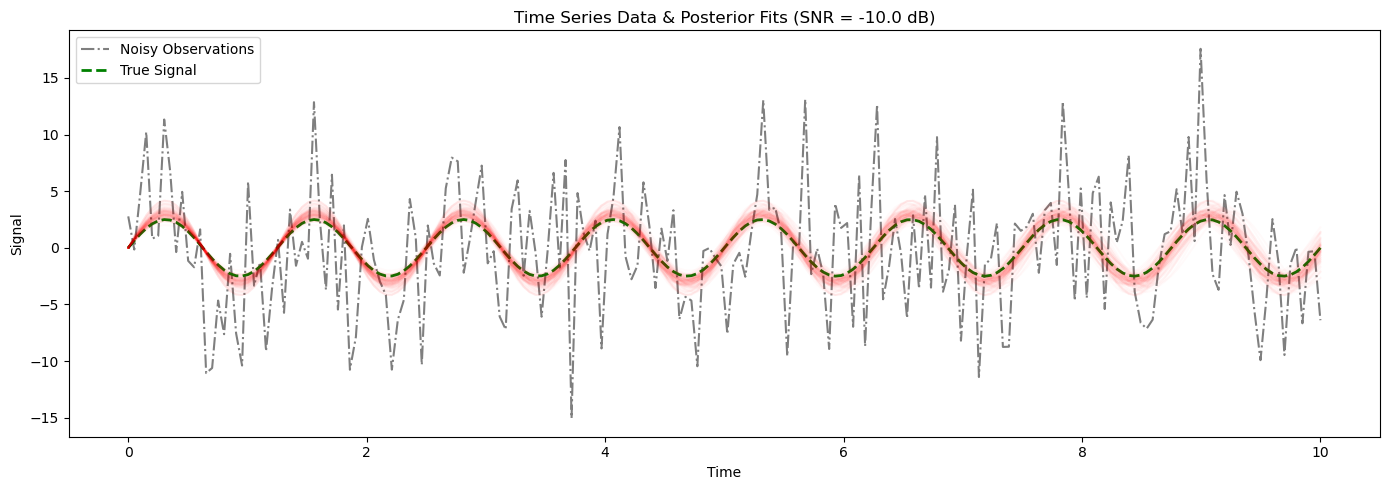

--- Data Generation Setup ---
Target SNR: -5.0 dB
Calculated Noise Std Dev (sigma): 3.144
-----------------------------

Starting Metropolis-Hastings MCMC...
MCMC Run Complete. Acceptance rate: 8.58%

--- Inference Results (95% Credible Intervals) ---
True Amplitude:  2.5
Estimated Amp:   2.424 (95% CI: [1.725, 3.047])
True Frequency:  0.8
Estimated Freq:  0.802 (95% CI: [0.796, 0.809])


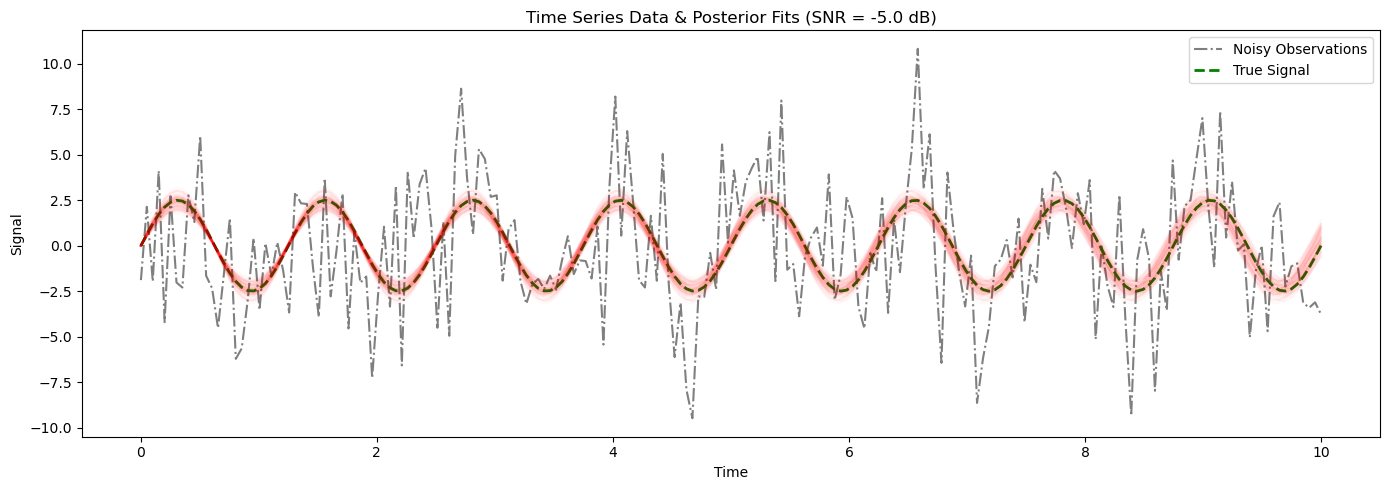

--- Data Generation Setup ---
Target SNR: 5.0 dB
Calculated Noise Std Dev (sigma): 0.994
-----------------------------

Starting Metropolis-Hastings MCMC...
MCMC Run Complete. Acceptance rate: 7.08%

--- Inference Results (95% Credible Intervals) ---
True Amplitude:  2.5
Estimated Amp:   1.472 (95% CI: [0.266, 2.585])
True Frequency:  0.8
Estimated Freq:  0.694 (95% CI: [0.567, 0.799])


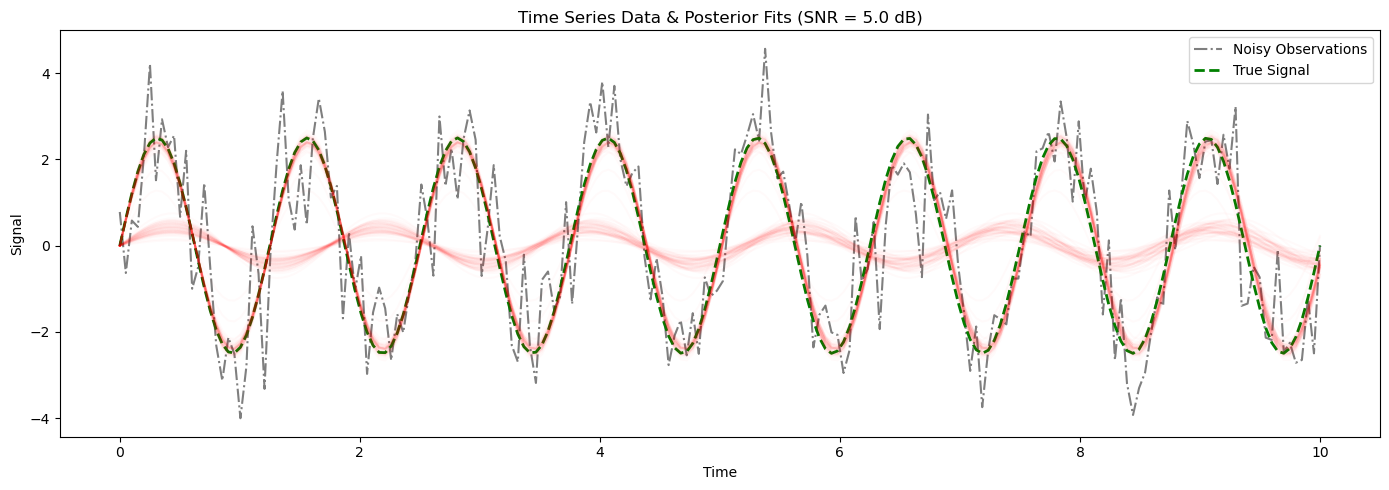

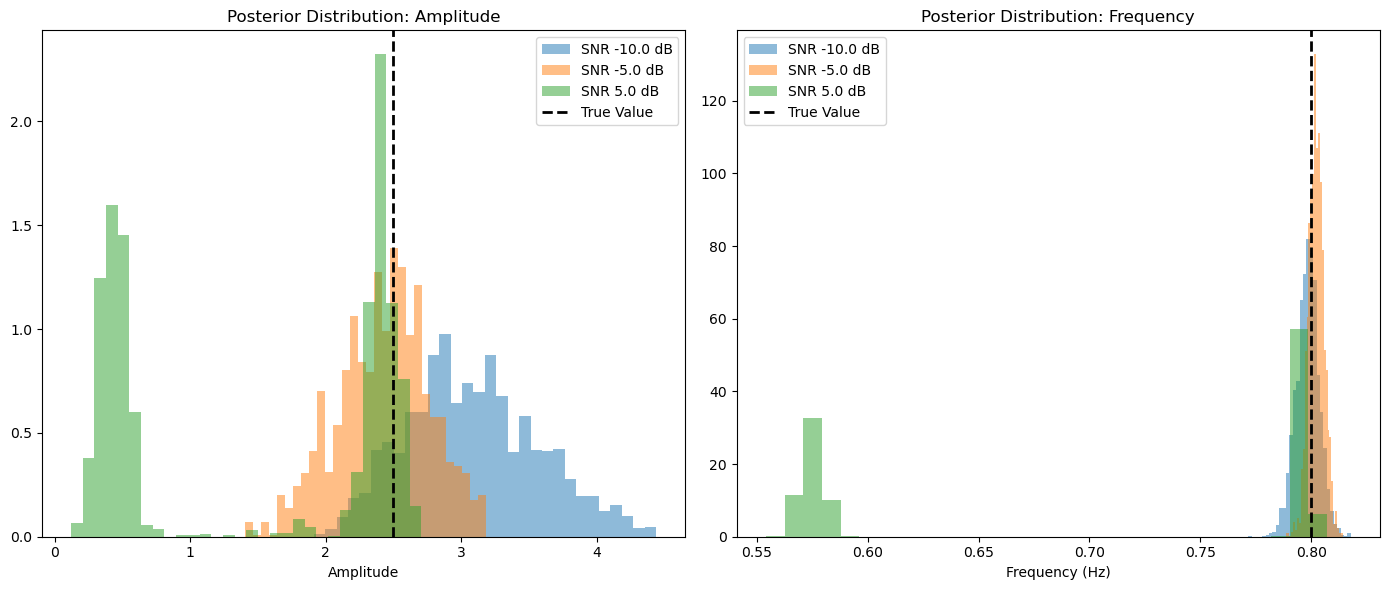

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. GENERATE SYNTHETIC DATA & CONFIGURE SNR
# We create a noisy monochromatic sine wave. This represents our
# "observed data" (D) from an experiment.
# =====================================================================
np.random.seed(42)  # For reproducibility

# Time array
t = np.linspace(0, 10, 200)


def generate_synthetic_data(SNR_dB, A_true, f_true):
    # --- NEW: Signal-to-Noise Ratio (SNR) Flexibility ---
    # Set the desired SNR in Decibels (dB).
    # High SNR (e.g., 20) = very little noise.
    # Low SNR (e.g., 0 or negative) = noise dominates the signal.
    # SNR_dB = 5.0

    # Calculate the required noise standard deviation (sigma) to achieve the target SNR
    # Signal power of a sine wave is A^2 / 2
    signal_power = (A_true**2) / 2
    # Convert SNR from dB to linear scale to find required noise power
    noise_power = signal_power / (10 ** (SNR_dB / 10))
    sigma_true = np.sqrt(noise_power)

    print(f"--- Data Generation Setup ---")
    print(f"Target SNR: {SNR_dB} dB")
    print(f"Calculated Noise Std Dev (sigma): {sigma_true:.3f}")
    print(f"-----------------------------\n")

    # Generate the true signal and add the calculated Gaussian noise
    y_true = A_true * np.sin(2 * np.pi * f_true * t)
    y_obs = y_true + np.random.normal(0, sigma_true, size=len(t))
    return y_true, y_obs, sigma_true


# =====================================================================
# 2. DEFINE THE BAYESIAN MODEL
# We need functions to calculate the Prior, Likelihood, and Posterior.
# We compute everything in log-space to prevent numerical underflow.
# =====================================================================


def log_prior(theta):
    """
    Log-Prior: Encodes our belief before seeing data.
    We assume Uniform priors: Amplitude between [0, 5], Frequency between [0, 2].
    """
    A, f = theta
    if 0.0 < A < 5.0 and 0.0 < f < 2.0:
        return 0.0  # Log of a constant (proportional)
    return -np.inf  # Log of zero probability


def log_likelihood(theta, t, y_obs, sigma):
    """
    Log-Likelihood: The probability of the data given the parameters.
    Assuming Gaussian noise, this is proportional to the negative sum
    of squared residuals.
    """
    A, f = theta
    y_model = A * np.sin(2 * np.pi * f * t)
    # log( Gaussian PDF )
    return -0.5 * np.sum(((y_obs - y_model) / sigma) ** 2)


def log_posterior(theta, t, y_obs, sigma):
    """
    Log-Posterior: Log-Prior + Log-Likelihood (from Bayes' Theorem)
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf  # If prior is 0, posterior is 0
    return lp + log_likelihood(theta, t, y_obs, sigma)


# =====================================================================
# 3. METROPOLIS-HASTINGS MCMC ALGORITHM
# =====================================================================


def metropolis_hastings(iterations, initial_theta, t, y_obs, sigma, proposal_width):
    # Initialize state
    curr_theta = np.array(initial_theta)
    curr_lp = log_posterior(curr_theta, t, y_obs, sigma)

    # Pre-allocate array to store the chain of samples
    samples = np.zeros((iterations, 2))
    accepted = 0

    for i in range(iterations):
        # Step 1: Propose a new state by adding Gaussian noise to the current state
        prop_theta = curr_theta + np.random.normal(0, proposal_width, size=2)

        # Step 2: Evaluate the log-posterior of the proposed state
        prop_lp = log_posterior(prop_theta, t, y_obs, sigma)

        # Step 3: Calculate acceptance ratio (in log space: log(A/B) = logA - logB)
        log_alpha = prop_lp - curr_lp

        # Step 4: Accept or Reject
        # np.log(np.random.rand()) generates a log-uniform random variable
        if np.log(np.random.rand()) < log_alpha:
            curr_theta = prop_theta
            curr_lp = prop_lp
            accepted += 1

        # Store the current state (even if we rejected the proposal)
        samples[i] = curr_theta

    print(f"MCMC Run Complete. Acceptance rate: {accepted / iterations:.2%}")
    return samples


# =====================================================================
# 4. RUN THE INFERENCE
# =====================================================================
# "True" underlying physics parameters
A_true = 2.5  # True Amplitude
f_true = 0.8  # True Frequency (Hz)

# Create a dictionary to store posteriors for all SNRs
posteriors = {}

for SNR_dB in [-10.0, -5.0, 5.0]:
    y_true, y_obs, sigma_true = generate_synthetic_data(SNR_dB, A_true, f_true)

    iterations = 20000
    initial_guess = [1.0, 0.5]  # Starting arbitrarily
    proposal_width = [0.1, 0.05]  # Step size for the random walk

    print("Starting Metropolis-Hastings MCMC...")
    chain = metropolis_hastings(
        iterations, initial_guess, t, y_obs, sigma_true, proposal_width
    )

    # Discard the first 20% of samples as "burn-in" (time taken to find the high probability region)
    burn_in = int(0.2 * iterations)
    valid_samples = chain[burn_in:]

    A_samples = valid_samples[:, 0]
    f_samples = valid_samples[:, 1]

    # Store samples for later joint plotting
    posteriors[SNR_dB] = (A_samples, f_samples)

    # =====================================================================
    # 5. CALCULATE CREDIBLE INTERVALS
    # =====================================================================
    A_ci = np.percentile(A_samples, [2.5, 97.5])
    f_ci = np.percentile(f_samples, [2.5, 97.5])

    print("\n--- Inference Results (95% Credible Intervals) ---")
    print(f"True Amplitude:  {A_true}")
    print(
        f"Estimated Amp:   {np.mean(A_samples):.3f} (95% CI: [{A_ci[0]:.3f}, {A_ci[1]:.3f}])"
    )
    print(f"True Frequency:  {f_true}")
    print(
        f"Estimated Freq:  {np.mean(f_samples):.3f} (95% CI: [{f_ci[0]:.3f}, {f_ci[1]:.3f}])"
    )

    # =====================================================================
    # 6. VISUALIZATION (Time Series Fit)
    # =====================================================================
    fig_data = plt.figure(figsize=(14, 5))
    ax1 = plt.gca()
    ax1.plot(t, y_obs, "k-.", alpha=0.5, label="Noisy Observations")
    ax1.plot(t, y_true, "g--", linewidth=2, label="True Signal")

    # Plot 100 random samples from the posterior to show uncertainty
    for idx in np.random.randint(0, len(valid_samples), 100):
        A_s, f_s = valid_samples[idx]
        ax1.plot(t, A_s * np.sin(2 * np.pi * f_s * t), "r-", alpha=0.02)

    ax1.set_title(f"Time Series Data & Posterior Fits (SNR = {SNR_dB} dB)")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Signal")
    ax1.legend()
    plt.tight_layout()
    plt.show()

# =====================================================================
# 7. OVERLAID POSTERIORS
# =====================================================================
fig_post, (ax_amp, ax_freq) = plt.subplots(1, 2, figsize=(14, 6))

for SNR_dB, (A_samples, f_samples) in posteriors.items():
    # Use histtype='stepfilled' or set alpha so they don't block each other
    ax_amp.hist(A_samples, bins=30, density=True, alpha=0.5, label=f"SNR {SNR_dB} dB")
    ax_freq.hist(f_samples, bins=30, density=True, alpha=0.5, label=f"SNR {SNR_dB} dB")

ax_amp.axvline(A_true, color="k", linestyle="dashed", linewidth=2, label="True Value")
ax_amp.set_title("Posterior Distribution: Amplitude")
ax_amp.set_xlabel("Amplitude")
ax_amp.legend()

ax_freq.axvline(f_true, color="k", linestyle="dashed", linewidth=2, label="True Value")
ax_freq.set_title("Posterior Distribution: Frequency")
ax_freq.set_xlabel("Frequency (Hz)")
ax_freq.legend()

plt.tight_layout()
plt.show()

## 7. Tying It All Together: Solving the Inference Problem

Let us pause and concretely connect Sections 1 through 6. We started with a fundamental problem in physics and statistics: we want to understand the true parameters $\theta$ of a physical system based on noisy, observed data $D$.

1. Our Goal: Bayesian inference (Section 2 & 3) tells us everything we need to know is contained in the posterior distribution $p(\theta|D)$. If we want the best estimate of a parameter, we must calculate its expected value over this distribution: $\mathbb{E}[\theta|D] = \int \theta \, p(\theta|D) d\theta$.

1. The Roadblock: To evaluate this integral, we need the exact posterior density. However, Bayes' theorem contains an intractable denominator $p(D)$ (the Bayesian evidence). We only realistically have access to the unnormalized density $\pi(\theta) = p(D|\theta)p(\theta)$.

1. The MCMC Bridge: The Metropolis-Hastings algorithm (Section 6), grounded in the mathematics of Markov Chains (Section 4 + 5), rescues us. By constructing a Markov chain using only the ratio of probabilities—where the intractable Bayesian evidence perfectly cancels out—we can generate a sequence of samples $\theta_1, \theta_2, \dots, \theta_N$.

1. Our Resolution: Because the stationary distribution of this specific chain is the true posterior $p(\theta|D)$, the samples we collected are formally drawn from the exact distribution we care about, even without knowing its normalizing constant!

We can now plug these MCMC samples directly back into the standard Monte Carlo formula from Section 1! The impossible integral reduces to simple arithmetic on our drawn samples:

$$\mathbb{E}[\theta|D] \approx \frac{1}{N} \sum_{i=1}^N \theta_i$$

Similarly, if we want a 95% credible interval to quantify our uncertainty, we bypass complex calculus entirely and simply locate the 2.5th and 97.5th percentiles of our generated samples.

By combining Monte Carlo averaging with Markov Chain sampling, we have successfully transformed an analytically unsolvable, high-dimensional calculus problem into a straightforward algorithmic simulation task.

## 8. Hypothesis Testing

Once we have posteriors (perhaps via MCMC), how do we make scientific decisions? We test hypotheses.

### 8.1 The Frequentist Paradigm (Brief Overview)

In frequentist statistics, we define a Null Hypothesis $H_0$. We calculate a test statistic $T$ from the data $D$.
The $p$-value is defined as $P(T \geq T_{obs} | H_0)$.
If the $p$-value $< \alpha$ (usually 0.05), we reject $H_0$.

*However*, the $p$-value tells us $P(Data | H_0)$. It does not tell us $P(H_0 | Data)$, which is usually what we actually want to know.



### 8.2 The Bayesian Paradigm: Bayes Factors

Bayesian hypothesis testing directly compares the probability of two hypotheses, $H_0$ and $H_1$, given the data $D$.
Using Bayes' theorem for models:

$$\frac{P(H_1 | D)}{P(H_0 | D)} = \underbrace{\frac{P(D | H_1)}{P(D | H_0)}}_{\text{Bayes Factor (K)}} \times \underbrace{\frac{P(H_1)}{P(H_0)}}_{\text{Prior Odds}}$$

The *Bayes Factor ($K$)* measures the relative evidence provided by the data for $H_1$ over $H_0$.

$$K = \frac{P(D | H_1)}{P(D | H_0)}$$

Where $P(D | H_k)$ is the marginal likelihood (**evidence**) for model $k$:

$$P(D | H_k) = \int P(D | \theta_k, H_k) p(\theta_k | H_k) d\theta_k$$

**Interpretation of K (Jeffreys' Scale)**

- $K > 10$: Strong evidence for $H_1$

- $3 < K < 10$: Substantial evidence for $H_1$

- $1 < K < 3$: Barely worth mentioning

- $K < 1$: Evidence favors $H_0$

#### 8.2.1 When to use Bayesian Hypothesis Testing (Bayes Factors):

- When you want to directly quantify the probability of hypotheses.

- When you want to prove the Null Hypothesis (frequentist p-values can only reject the null, Bayes factors can accumulate evidence for the null).

- When doing sequential testing (you can update Bayes Factors as new data arrives without standard "p-hacking" multiple testing penalties).



## 9. Model Selection

In machine learning and statistics, we often have a set of candidate models $\mathcal{M} = \{M_1, M_2, \dots, M_k\}$ with varying complexity (e.g., polynomial regression of degree 1 vs degree 10). We want to select a model that fits the data well but does not overfit.

### 9.1 Occam's Razor and Marginal Likelihood

The Bayesian marginal likelihood $P(D | M)$ naturally encodes a penalty for complexity (Bayesian Occam's Razor). A complex model can fit many datasets reasonably well, spreading its probability mass thin. A simple model can only fit a few datasets, but allocates high probability mass to them. If the simple model fits the actual data $D$, $P(D | M_{simple}) > P(D | M_{complex})$.

However, calculating the Bayesian evidence $P(D | M) = \int P(D | \theta_M) p(\theta_M) d\theta_M$ is precisely the intractable integral we discussed earlier. While we can use MCMC to approximate it (e.g., via bridge sampling), Information Criteria provide fast, asymptotic approximations.

### 9.2 Bayesian Information Criterion (BIC)

The BIC is an asymptotic approximation to the log of the Bayesian evidence (marginal likelihood). For a model with $k$ parameters and $N$ data points:

$$\text{BIC} = -2 \log(L_{max}) + k \log(N)$$

Where $L_{max} = p(D | \hat{\theta}_{MLE})$ is the maximized likelihood. We select the model that minimizes the BIC.

**Relation to Bayes Factors**

Because the BIC approximates the log of the Bayesian evidence ($\log P(D|M) \approx -\frac{1}{2} \text{BIC}$), it provides a direct, computationally cheap way to estimate the Bayes Factor $K$ between two competing models, $M_1$ and $M_2$, without solving complex integrals:

$$\log K = \log \left( \frac{P(D | M_1)}{P(D | M_2)} \right) = \log P(D | M_1) - \log P(D | M_2)$$

Substituting the BIC approximation:

$$\boxed{\log K \approx -\frac{1}{2} \text{BIC}_1 - \left( -\frac{1}{2} \text{BIC}_2 \right) = -\frac{1}{2} (\text{BIC}_1 - \text{BIC}_2) = -\frac{1}{2} \Delta \text{BIC}}$$

This demonstrates that differences in BIC scores ($\Delta \text{BIC}$) directly translate into the Bayes Factor, explicitly revealing the evidence favoring one model over another.



### 8.3 Optional
**Derivation: From Laplace Approximation to BIC**

We wish to approximate $\log P(D) = \log \int P(D|\theta) P(\theta) d\theta$.
Let $h(\theta) = \log P(D|\theta) + \log P(\theta)$. The integral is $\int e^{h(\theta)} d\theta$.
We Taylor expand $h(\theta)$ around the Maximum a Posteriori (MAP) estimate $\hat{\theta}$:

$$h(\theta) \approx h(\hat{\theta}) + (\theta - \hat{\theta})^T \nabla h(\hat{\theta}) + \frac{1}{2} (\theta - \hat{\theta})^T H (\theta - \hat{\theta})$$

Since $\hat{\theta}$ is a maximum, the gradient $\nabla h(\hat{\theta}) = 0$. $H$ is the Hessian matrix of second derivatives at $\hat{\theta}$.

$$\int e^{h(\theta)} d\theta \approx e^{h(\hat{\theta})} \int \exp\left( -\frac{1}{2} (\theta - \hat{\theta})^T (-H) (\theta - \hat{\theta}) \right) d\theta$$

This is an unnormalized multivariate Gaussian integral. Solving it yields:

$$\int e^{h(\theta)} d\theta \approx e^{h(\hat{\theta})} (2\pi)^{k/2} |-H|^{-1/2}$$

Taking the log of both sides:

$$\log P(D) \approx h(\hat{\theta}) + \frac{k}{2} \log(2\pi) - \frac{1}{2} \log |-H|$$

Expand $h(\hat{\theta})$:

$$\log P(D) \approx \log P(D|\hat{\theta}) + \log P(\hat{\theta}) + \frac{k}{2} \log(2\pi) - \frac{1}{2} \log |-H|$$

**Asymptotic arguments ($N \to \infty$):**

1. As $N$ grows, the likelihood dominates the prior, so $\hat{\theta}_{MAP} \to \hat{\theta}_{MLE}$.

2. The prior term $\log P(\hat{\theta})$ becomes constant/negligible relative to $N$.

3. The Hessian $H$ is a sum over $N$ data points (Fisher Information Matrix). So $H \approx N \cdot H_0$ (where $H_0$ is the per-observation info matrix).

4. Therefore, the determinant $|-H| \approx |N \cdot H_0| = N^k |-H_0|$.

5. $\log |-H| \approx k \log N + \log |-H_0|$. As $N \to \infty$, $k \log N$ dominates.

Substituting these approximations back:

$$\log P(D) \approx \log P(D|\hat{\theta}_{MLE}) - \frac{k}{2} \log N$$

Multiplying by $-2$ (historical convention from deviance) gives the standard BIC formula:

$$\text{BIC} \approx -2 \log P(D) = -2 \log P(D|\hat{\theta}_{MLE}) + k \log N$$

$\blacksquare$



### 8.4 When to use Model Selection Criteria (BIC/AIC):

- When you need a quick, computationally cheap way to compare models without running full MCMC to calculate marginal likelihoods.

- **AIC vs BIC**: Use **BIC** when you believe the "true model" is in your candidate set and you want to find it (consistent for model identification, penalizes complexity heavily with $k \log N$). Use **AIC** (Akaike Information Criterion, penalty is $2k$) when you care more about predictive performance and don't necessarily believe any model is exactly "true".

--- Data Generation Setup ---
Target SNR: 5.0 dB
Calculated Noise Std Dev (sigma): 0.994
-----------------------------

Starting MCMC for Hypothesis 1 (Sine)...
MCMC Run Complete (model_sine). Acceptance rate: 2.33%
Starting MCMC for Hypothesis 2 (Sine Cubed)...
MCMC Run Complete (model_sine_cubed). Acceptance rate: 2.83%

--- Inference Results for H1 (Sine) ---
True Amplitude:  2.5
Estimated Amp:   2.587 (95% CI: [2.404, 2.816])
True Frequency:  0.8
Estimated Freq:  0.800 (95% CI: [0.798, 0.802])

--- Inference Results for H2 (Sine Cubed) ---
Estimated Amp:   3.127 (95% CI: [2.871, 3.405])
Estimated Freq:  0.799 (95% CI: [0.797, 0.801])

--- Hypothesis Testing Results ---
H1 (Sine) Max Log-Likelihood: -86.10, BIC: 182.80
H2 (Sine Cubed) Max Log-Likelihood: -112.42, BIC: 235.43
Log Bayes Factor ln(K): 26.32
Bayes Factor K (H1 over H2): 2.69e+11
Conclusion: Strong evidence for H1 (Sine wave) over H2 (Sine Cubed).


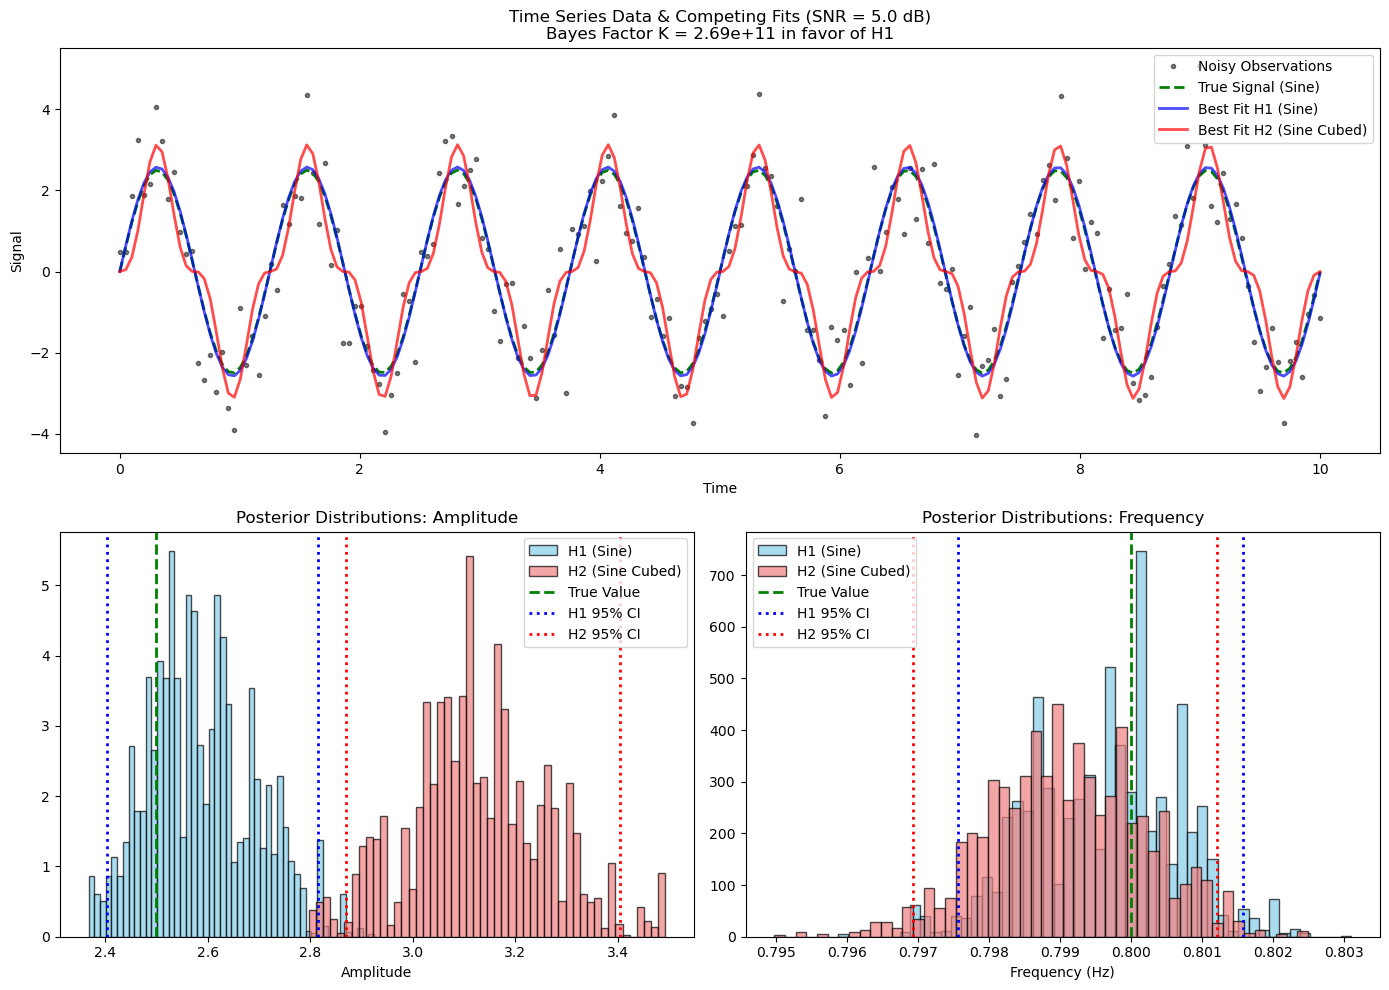

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. GENERATE SYNTHETIC DATA & CONFIGURE SNR
# We create a noisy monochromatic sine wave. This represents our
# "observed data" (D) from an experiment.
# =====================================================================
np.random.seed(42) # For reproducibility

# Time array
t = np.linspace(0, 10, 200)

# "True" underlying physics parameters
A_true = 2.5      # True Amplitude
f_true = 0.8      # True Frequency (Hz)

# --- NEW: Signal-to-Noise Ratio (SNR) Flexibility ---
# Set the desired SNR in Decibels (dB). 
# High SNR (e.g., 20) = very little noise. 
# Low SNR (e.g., 0 or negative) = noise dominates the signal.
SNR_dB = 5.0 

# Calculate the required noise standard deviation (sigma) to achieve the target SNR
# Signal power of a sine wave is A^2 / 2
signal_power = (A_true ** 2) / 2
# Convert SNR from dB to linear scale to find required noise power
noise_power = signal_power / (10 ** (SNR_dB / 10))
sigma_true = np.sqrt(noise_power)

print(f"--- Data Generation Setup ---")
print(f"Target SNR: {SNR_dB} dB")
print(f"Calculated Noise Std Dev (sigma): {sigma_true:.3f}")
print(f"-----------------------------\n")

# Generate the true signal and add the calculated Gaussian noise
y_true = A_true * np.sin(2 * np.pi * f_true * t)
y_obs = y_true + np.random.normal(0, sigma_true, size=len(t))

# =====================================================================
# 2. DEFINE THE BAYESIAN MODEL
# We need functions to calculate the Prior, Likelihood, and Posterior.
# We compute everything in log-space to prevent numerical underflow.
# =====================================================================

def log_prior(theta):
    """
    Log-Prior: Encodes our belief before seeing data.
    We assume Uniform priors: Amplitude between [0, 5], Frequency between [0, 2].
    """
    A, f = theta
    if 0.0 < A < 5.0 and 0.0 < f < 2.0:
        return 0.0 # Log of a constant (proportional)
    return -np.inf # Log of zero probability

def model_sine(theta, t):
    A, f = theta
    return A * np.sin(2 * np.pi * f * t)

def model_sine_cubed(theta, t):
    A, f = theta
    return A * (np.sin(2 * np.pi * f * t) ** 3)

def log_likelihood(theta, t, y_obs, sigma, model_func):
    """
    Log-Likelihood: The probability of the data given the parameters.
    Assuming Gaussian noise, this is proportional to the negative sum 
    of squared residuals.
    """
    y_model = model_func(theta, t)
    # log( Gaussian PDF )
    return -0.5 * np.sum(((y_obs - y_model) / sigma) ** 2)

def log_posterior(theta, t, y_obs, sigma, model_func):
    """
    Log-Posterior: Log-Prior + Log-Likelihood (from Bayes' Theorem)
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf # If prior is 0, posterior is 0
    return lp + log_likelihood(theta, t, y_obs, sigma, model_func)

# =====================================================================
# 3. METROPOLIS-HASTINGS MCMC ALGORITHM
# =====================================================================

def metropolis_hastings(iterations, initial_theta, t, y_obs, sigma, proposal_width, model_func):
    # Initialize state
    curr_theta = np.array(initial_theta)
    curr_lp = log_posterior(curr_theta, t, y_obs, sigma, model_func)
    
    # Pre-allocate array to store the chain of samples
    samples = np.zeros((iterations, 2))
    accepted = 0
    
    for i in range(iterations):
        # Step 1: Propose a new state by adding Gaussian noise to the current state
        prop_theta = curr_theta + np.random.normal(0, proposal_width, size=2)
        
        # Step 2: Evaluate the log-posterior of the proposed state
        prop_lp = log_posterior(prop_theta, t, y_obs, sigma, model_func)
        
        # Step 3: Calculate acceptance ratio (in log space: log(A/B) = logA - logB)
        log_alpha = prop_lp - curr_lp
        
        # Step 4: Accept or Reject
        # np.log(np.random.rand()) generates a log-uniform random variable
        if np.log(np.random.rand()) < log_alpha:
            curr_theta = prop_theta
            curr_lp = prop_lp
            accepted += 1
            
        # Store the current state (even if we rejected the proposal)
        samples[i] = curr_theta
        
    print(f"MCMC Run Complete ({model_func.__name__}). Acceptance rate: {accepted / iterations:.2%}")
    return samples

# =====================================================================
# 4. RUN THE INFERENCE
# =====================================================================
iterations = 20000
initial_guess = [1.0, 0.5] # Starting arbitrarily
proposal_width = [0.1, 0.05] # Step size for the random walk

print("Starting MCMC for Hypothesis 1 (Sine)...")
chain_m1 = metropolis_hastings(iterations, initial_guess, t, y_obs, sigma_true, proposal_width, model_sine)

print("Starting MCMC for Hypothesis 2 (Sine Cubed)...")
chain_m2 = metropolis_hastings(iterations, initial_guess, t, y_obs, sigma_true, proposal_width, model_sine_cubed)

# Discard the first 20% of samples as "burn-in"
burn_in = int(0.2 * iterations)
valid_samples_m1 = chain_m1[burn_in:]
valid_samples_m2 = chain_m2[burn_in:]

A_samples_m1 = valid_samples_m1[:, 0]
f_samples_m1 = valid_samples_m1[:, 1]

A_samples_m2 = valid_samples_m2[:, 0]
f_samples_m2 = valid_samples_m2[:, 1]

# =====================================================================
# 5. HYPOTHESIS TESTING & CREDIBLE INTERVALS
# =====================================================================
# Calculate 95% credible intervals for both models
A_ci_m1 = np.percentile(A_samples_m1, [2.5, 97.5])
f_ci_m1 = np.percentile(f_samples_m1, [2.5, 97.5])

A_ci_m2 = np.percentile(A_samples_m2, [2.5, 97.5])
f_ci_m2 = np.percentile(f_samples_m2, [2.5, 97.5])

print("\n--- Inference Results for H1 (Sine) ---")
print(f"True Amplitude:  {A_true}")
print(f"Estimated Amp:   {np.mean(A_samples_m1):.3f} (95% CI: [{A_ci_m1[0]:.3f}, {A_ci_m1[1]:.3f}])")
print(f"True Frequency:  {f_true}")
print(f"Estimated Freq:  {np.mean(f_samples_m1):.3f} (95% CI: [{f_ci_m1[0]:.3f}, {f_ci_m1[1]:.3f}])")

print("\n--- Inference Results for H2 (Sine Cubed) ---")
print(f"Estimated Amp:   {np.mean(A_samples_m2):.3f} (95% CI: [{A_ci_m2[0]:.3f}, {A_ci_m2[1]:.3f}])")
print(f"Estimated Freq:  {np.mean(f_samples_m2):.3f} (95% CI: [{f_ci_m2[0]:.3f}, {f_ci_m2[1]:.3f}])")

# Hypothesis Testing (Bayes Factors via BIC Approximation)
def get_max_log_likelihood(samples, model_func):
    lls = [log_likelihood(s, t, y_obs, sigma_true, model_func) for s in samples]
    return np.max(lls)

L_max_1 = get_max_log_likelihood(valid_samples_m1, model_sine)
L_max_2 = get_max_log_likelihood(valid_samples_m2, model_sine_cubed)

N = len(y_obs)
k = 2 # Both models have 2 parameters

# BIC = -2 * ln(L_max) + k * ln(N)
bic_1 = -2 * L_max_1 + k * np.log(N)
bic_2 = -2 * L_max_2 + k * np.log(N)

# Approx Log Bayes Factor: ln(K) ≈ -0.5 * (BIC_1 - BIC_2)
log_K = -0.5 * (bic_1 - bic_2)
K = np.exp(log_K)

print("\n--- Hypothesis Testing Results ---")
print(f"H1 (Sine) Max Log-Likelihood: {L_max_1:.2f}, BIC: {bic_1:.2f}")
print(f"H2 (Sine Cubed) Max Log-Likelihood: {L_max_2:.2f}, BIC: {bic_2:.2f}")
print(f"Log Bayes Factor ln(K): {log_K:.2f}")
print(f"Bayes Factor K (H1 over H2): {K:.2e}")
if K > 10:
    print("Conclusion: Strong evidence for H1 (Sine wave) over H2 (Sine Cubed).")
elif K < 0.1:
    print("Conclusion: Strong evidence for H2 (Sine Cubed) over H1 (Sine wave).")
else:
    print("Conclusion: Evidence is inconclusive.")

# =====================================================================
# 6. VISUALIZATION
# =====================================================================
fig = plt.figure(figsize=(14, 10))

# Plot 1: The Data and the Fit
ax1 = plt.subplot(2, 2, (1, 2))
ax1.plot(t, y_obs, 'k.', alpha=0.5, label='Noisy Observations')
ax1.plot(t, y_true, 'g--', linewidth=2, label='True Signal (Sine)')

# Find the best fits to plot
best_theta_1 = valid_samples_m1[np.argmax([log_likelihood(s, t, y_obs, sigma_true, model_sine) for s in valid_samples_m1])]
best_theta_2 = valid_samples_m2[np.argmax([log_likelihood(s, t, y_obs, sigma_true, model_sine_cubed) for s in valid_samples_m2])]

ax1.plot(t, model_sine(best_theta_1, t), 'b-', linewidth=2, alpha=0.7, label='Best Fit H1 (Sine)')
ax1.plot(t, model_sine_cubed(best_theta_2, t), 'r-', linewidth=2, alpha=0.7, label='Best Fit H2 (Sine Cubed)')
    
ax1.set_title(f"Time Series Data & Competing Fits (SNR = {SNR_dB} dB)\nBayes Factor K = {K:.2e} in favor of H1")
ax1.set_xlabel("Time")
ax1.set_ylabel("Signal")
ax1.legend()

# Plot 2: Amplitude Posterior
ax2 = plt.subplot(2, 2, 3)
ax2.hist(A_samples_m1, bins=50, density=True, color='skyblue', alpha=0.7, edgecolor='black', label='H1 (Sine)')
ax2.hist(A_samples_m2, bins=50, density=True, color='lightcoral', alpha=0.7, edgecolor='black', label='H2 (Sine Cubed)')
ax2.axvline(A_true, color='g', linestyle='dashed', linewidth=2, label='True Value')
ax2.axvline(A_ci_m1[0], color='blue', linestyle='dotted', linewidth=2, label='H1 95% CI')
ax2.axvline(A_ci_m1[1], color='blue', linestyle='dotted', linewidth=2)
ax2.axvline(A_ci_m2[0], color='red', linestyle='dotted', linewidth=2, label='H2 95% CI')
ax2.axvline(A_ci_m2[1], color='red', linestyle='dotted', linewidth=2)
ax2.set_title("Posterior Distributions: Amplitude")
ax2.set_xlabel("Amplitude")
ax2.legend()

# Plot 3: Frequency Posterior
ax3 = plt.subplot(2, 2, 4)
ax3.hist(f_samples_m1, bins=50, density=True, color='skyblue', alpha=0.7, edgecolor='black', label='H1 (Sine)')
ax3.hist(f_samples_m2, bins=50, density=True, color='lightcoral', alpha=0.7, edgecolor='black', label='H2 (Sine Cubed)')
ax3.axvline(f_true, color='g', linestyle='dashed', linewidth=2, label='True Value')
ax3.axvline(f_ci_m1[0], color='blue', linestyle='dotted', linewidth=2, label='H1 95% CI')
ax3.axvline(f_ci_m1[1], color='blue', linestyle='dotted', linewidth=2)
ax3.axvline(f_ci_m2[0], color='red', linestyle='dotted', linewidth=2, label='H2 95% CI')
ax3.axvline(f_ci_m2[1], color='red', linestyle='dotted', linewidth=2)
ax3.set_title("Posterior Distributions: Frequency")
ax3.set_xlabel("Frequency (Hz)")
ax3.legend()

plt.tight_layout()
plt.show()

## 9. Summary and Mathematical Hierarchy

1. The Goal: Calculate complex expectations and quantify uncertainty ($\mathbb{E}[f(X)]$).

1. The Tool: Monte Carlo Methods allow us to bypass intractable high-dimensional deterministic integration using independent random sampling.

1. The Foundation of Models: Statistical Inference bridges noisy real-world data to the parameters of theoretical physics.

1. The Complication: Bayesian Inference requires us to evaluate $p(\theta|D)$, but the normalizing constant $p(D)$ is a massive intractable integral, preventing direct independent sampling.

1. The Engine: Markov Chains provide a mathematical framework for dependent sequential processes that converge to stationary distributions.

1. The Workaround: MCMC integrates Monte Carlo and Markov chains, constructing a dependent chain that naturally converges to $p(\theta|D)$ without needing the denominator.

1. The Implementation: The Metropolis-Hastings Algorithm provides the rigorous mechanism—enforcing detailed balance—to guarantee our chain samples from the correct distribution.

1. The Application: With these posterior samples, we can make scientific decisions using Bayes Factors for hypothesis testing, or deploy approximations like BIC for rapid model selection.

Understanding the rigorous mathematical bridges between these concepts—from the Central Limit Theorem in standard MC, to the Chapman-Kolmogorov equations in Markov Chains, to Detailed Balance in MCMC, to the Laplace approximation in BIC—is essential for applying statistical machine learning effectively in practice.